<a href="https://colab.research.google.com/github/srushtinagaraju/Machine_Learning_1BM24CS424/blob/main/1BM24CS424_Lab-11%20K-Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iris (1) (1).csv to iris (1) (1).csv


Columns: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


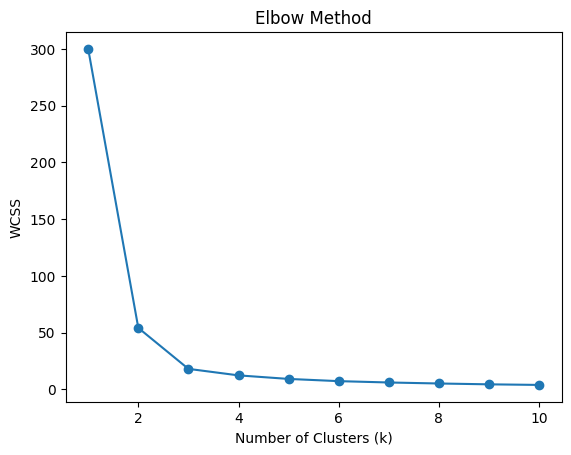

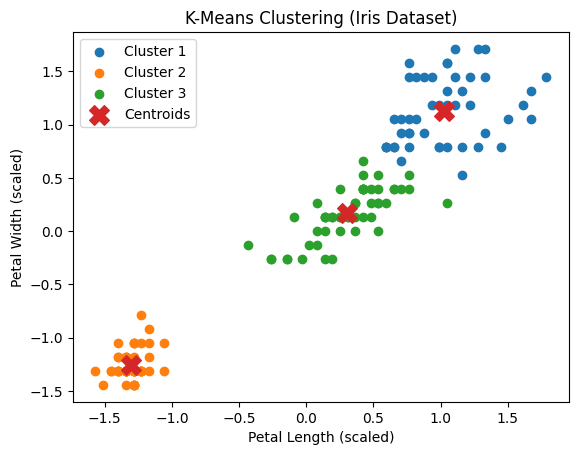

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Load dataset
df = pd.read_csv("iris (1) (1).csv")

print("Columns:", df.columns)
print(df.head())

# Step 3: Use only petal length & petal width
# (Adjust column names if needed)
X = df[['petal_length', 'petal_width']]

# Step 4: Scaling (IMPORTANT for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# STEP 5: Elbow Method
# -------------------------------
wcss = []   # Within Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# -------------------------------
# STEP 6: Choose optimal k
# (usually k=3 for Iris)
# -------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# -------------------------------
# STEP 7: Plot Clusters
# -------------------------------
plt.figure()

plt.scatter(X_scaled[y_pred == 0, 0], X_scaled[y_pred == 0, 1], label='Cluster 1')
plt.scatter(X_scaled[y_pred == 1, 0], X_scaled[y_pred == 1, 1], label='Cluster 2')
plt.scatter(X_scaled[y_pred == 2, 0], X_scaled[y_pred == 2, 1], label='Cluster 3')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200, label='Centroids')

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering (Iris Dataset)")
plt.legend()
plt.show()